# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
**Answer: Adding a penalty discourages the model from choosing very large coefficient values just to fit the training data extremely closely. A simpler model with smaller coefficients is usually more stable and less likely to chase random noise in the data.**

2. How does regularization provide a way of exploring the bias-variance trade-off?
**Answer: Regularization allows for control of model complexity. With little or no penalty, the model can fit the training data closely, which gives lower bias but higher variance. With a stronger penalty, the model becomes simpler, increasing bias but reducing variance. Penalty can be adjusted to find the best model performance.**

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
**Answer: Ridge regression uses a penalty based on the squared size of the coefficients, while LASSO uses a penalty based on the absolute size of the coefficients. Ridge usually shrinks coefficients toward zero but does not make them exactly zero, so it keeps all predictors in the model. LASSO can shrink some coefficients all the way to zero, so it can also perform variable selection and produce a sparser model.**

4. How do we typically scale variables for use in regularized regression? Why?
**Answer: We usually standardize predictors so that each variable has mean 0 and standard deviation 1. This is important because regularization depends on the size of the coefficients, so if variables are on very different scales, the penalty would affect them unevenly. Scaling makes the penalty fair across predictors.**

5. How is the penalty $\alpha$ typically selected?
**Answer: The penalty is usually chosen using cross-validation. This is done by trying many possible values of** **α, measuring how well each one performs on validation sets, and then picking the value that gives the best predictive performance.**


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
**Answer: No, the penalty term is not usually included when evaluating cross-validated MSE. The point of cross-validation is to measure how well the model predicts new data, so we care about prediction error on the response variable itself. The penalty is only used when fitting the model, not when judging prediction accuracy**

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path

#1)
cars = pd.read_csv("data/cars_hw.csv")
cars['Age'] = 2026 - cars['Make_Year']
X_base = cars[['Mileage_Run', 'Age']]
y = cars['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X = scaler.fit_transform(X_poly)

In [35]:

#2)
linreg = LinearRegression()
linreg.fit(X, y)
linreg_coefs = pd.Series(linreg.coef_, index=feature_names)
print("Linear Regression Coefficients")

print("\nInteraction term coefficient (Mileage_Run * Age):")
print(linreg_coefs["Mileage_Run Age"])


Linear Regression Coefficients

Interaction term coefficient (Mileage_Run * Age):
-1671212.3563918832


In [36]:
#3)
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=0)
lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("\nBest alpha:")
print(lasso_cv.alpha_)

print("\nLASSO coefficients:")
print(lasso_coefs)


Best alpha:
88.58667904100822

LASSO coefficients:
Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64


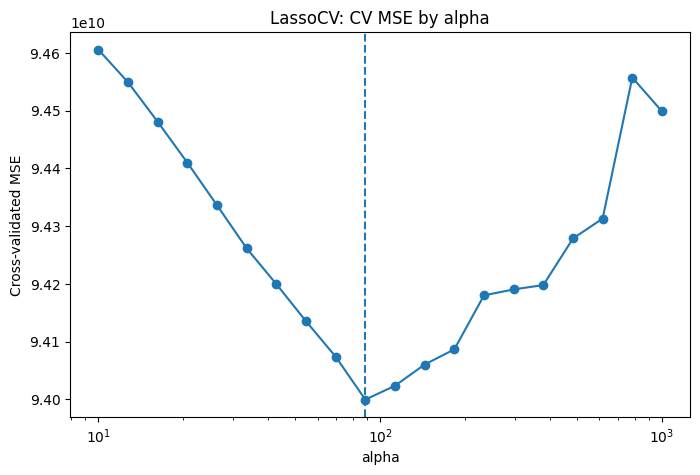

In [37]:
#4)
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker='o')
plt.axvline(lasso_cv.alpha_, linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LassoCV: CV MSE by alpha")
plt.show()

In [38]:
#5)
alpha_path = np.logspace(-5, 5, 100)
coef_path = []

for a in alpha_path:
    model = Lasso(alpha=a, max_iter=1000000)
    model.fit(X, y)
    coef_path.append(model.coef_)

In [39]:
#6)
selected_features = lasso_coefs[lasso_coefs != 0]
prop_zero = (lasso_coefs == 0).mean()

print("\nSelected features:")
print(selected_features)

print("\nProportion of coefficients set to zero:")
print(prop_zero)


Selected features:
Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

Proportion of coefficients set to zero:
0.1111111111111111


The LASSO sign pattern is more reasonable because regularization shrinks unstable coefficients and removes weak terms, which reduces variance and makes the model less sensitive to noise. Ordinary least squares has lower bias but can produce erratic signs when many correlated higher-order terms are included, while LASSO accepts a bit more bias in exchange for a more stable and interpretable fit.

In [40]:
#7)
comparison = pd.DataFrame({
    "LinearRegression": linreg_coefs,
    "LASSO": lasso_coefs
})

comparison["MagnitudeIncreased"] = comparison["LASSO"].abs() > comparison["LinearRegression"].abs()
comparison["ChangedSign"] = (
    (np.sign(comparison["LASSO"]) != np.sign(comparison["LinearRegression"])) &
    (comparison["LASSO"] != 0) &
    (comparison["LinearRegression"] != 0)
)

print("\nComparison table:")
print(comparison)

# Answers:
# Do any coefficients increase in magnitude from linear regression to LASSO?
increased = comparison[comparison['MagnitudeIncreased']]
if len(increased) > 0:
    print(f"\nYes, the following coefficients increased in magnitude: {list(increased.index)}")
else:
    print("\nNo coefficients increased in magnitude.")

# Do any change sign?
changed_sign = comparison[comparison['ChangedSign']]
if len(changed_sign) > 0:
    print(f"\nYes, the following coefficients changed sign: {list(changed_sign.index)}")
else:
    print("\nNo coefficients changed sign.")


Comparison table:
                   LinearRegression         LASSO  MagnitudeIncreased  \
Mileage_Run            9.117748e+05  7.790762e+05               False   
Age                   -2.481722e+05 -1.339534e+05               False   
Mileage_Run^2         -2.072926e+05 -2.015634e+05               False   
Mileage_Run Age       -1.671212e+06 -1.322419e+06               False   
Age^2                  3.505507e+05  0.000000e+00               False   
Mileage_Run^3         -6.514490e+04 -4.240952e+04               False   
Mileage_Run^2 Age      3.388195e+05  2.715062e+05               False   
Mileage_Run Age^2      7.167816e+05  5.415432e+05               False   
Age^3                 -2.100379e+05  1.374220e+04               False   

                   ChangedSign  
Mileage_Run              False  
Age                      False  
Mileage_Run^2            False  
Mileage_Run Age          False  
Age^2                    False  
Mileage_Run^3            False  
Mileage_Run^2 Age  

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [41]:
#1) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV

# Load data
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

# Response
y = df["DEATH_EVENT"].values

# Continuous variables for 3rd-degree polynomial expansion
cont_cols = ["age", "ejection_fraction", "serum_creatinine"]
X_cont_raw = df[cont_cols]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly_raw = poly_cont.fit_transform(X_cont_raw)
cont_feature_names = poly_cont.get_feature_names_out(cont_cols)

# z-score normalize the polynomial-expanded continuous block
scaler = StandardScaler()
X_cont_poly = scaler.fit_transform(X_cont_poly_raw)

# Dummy/categorical variables for interaction expansion
cat_cols = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
X_cat_raw = df[cat_cols]

# interaction_only=True with degree=4 gives main effects + pairwise + 3-way + 4-way interactions
poly_cat = PolynomialFeatures(degree=4, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat_raw)
cat_feature_names = poly_cat.get_feature_names_out(cat_cols)

# Concatenate into final feature matrix
X = np.hstack([X_cont_poly, X_cat_inter])
feature_names = list(cont_feature_names) + list(cat_feature_names)

X_df = pd.DataFrame(X, columns=feature_names)

print("X shape:", X.shape)
print("Number of features:", len(feature_names))
print(X_df.head())

X shape: (299, 34)
Number of features: 34
        age  ejection_fraction  serum_creatinine     age^2  \
0  1.192945          -1.530560          0.490057  1.177180   
1 -0.491279          -0.007077         -0.284552 -0.539187   
2  0.350833          -1.530560         -0.090900  0.252982   
3 -0.912335          -1.530560          0.490057 -0.885761   
4  0.350833          -1.530560          1.264666  0.252982   

   age ejection_fraction  age serum_creatinine  ejection_fraction^2  \
0              -0.939354              0.777328            -1.197120   
1              -0.267742             -0.365953            -0.146835   
2              -1.167019             -0.031334            -1.197120   
3              -1.508517              0.115061            -1.197120   
4              -1.167019              1.237428            -1.197120   

   ejection_fraction serum_creatinine  serum_creatinine^2     age^3  ...  \
0                           -0.287340            0.073541  1.124026  ...   
1     

In [42]:
#2) 

linreg = LinearRegression()
linreg.fit(X, y)

lin_coefs = pd.Series(linreg.coef_, index=feature_names)

print("Intercept:", linreg.intercept_)
print("\nLinear regression coefficients:")
print(lin_coefs.sort_values(key=np.abs, ascending=False))

# Compare simple marginal correlations with first-order coefficients
simple_corr = df[cont_cols + cat_cols + ["DEATH_EVENT"]].corr(numeric_only=True)["DEATH_EVENT"].drop("DEATH_EVENT")

first_order_features = cont_cols + cat_cols
comparison_rows = []
for feat in first_order_features:
    comparison_rows.append({
        "feature": feat,
        "simple_corr_with_DEATH_EVENT": simple_corr[feat],
        "linear_reg_first_order_coef": lin_coefs.get(feat, np.nan)
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\nSimple correlations vs first-order regression coefficients:")
print(comparison_df)

# Optional: inspect only first-order / lower-order terms
print("\nFirst-order terms only:")
print(lin_coefs[[f for f in first_order_features if f in lin_coefs.index]])

# Discussion: Are there any sign patterns that appear counterintuitive?
# For example, check if any first-order coefficients have opposite sign to correlation.
counterintuitive = comparison_df[
    (comparison_df['simple_corr_with_DEATH_EVENT'] > 0) & (comparison_df['linear_reg_first_order_coef'] < 0) |
    (comparison_df['simple_corr_with_DEATH_EVENT'] < 0) & (comparison_df['linear_reg_first_order_coef'] > 0)
]
if len(counterintuitive) > 0:
    print(f"\nCounterintuitive signs: {list(counterintuitive['feature'])}")
    print("This might happen due to multicollinearity or omitted variable bias. Higher-order terms or interactions can resolve this by capturing nonlinear relationships.")
else:
    print("\nNo counterintuitive signs observed.")

Intercept: 0.35572986885225105

Linear regression coefficients:
age^2                                          -3.717758
ejection_fraction^2                             3.352956
serum_creatinine^2                             -2.640240
ejection_fraction serum_creatinine              2.569764
ejection_fraction                              -2.062277
age^3                                           1.963124
age serum_creatinine                            1.707056
age ejection_fraction serum_creatinine         -1.626996
age                                             1.619432
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction serum_creatinine^2            1.189516
ejection_fraction^2 serum_creatinine           -1.151378
age^2 ejection_fraction                         1.054408
age ejection_fraction                          -0.800726
serum_creatinine                               -0.757092
age^2 serum_creatinine  

In [43]:
#3) 
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    random_state=42,
    max_iter=100000
)

lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("Optimal alpha:", lasso_cv.alpha_)
print("Number of nonzero coefficients:", (lasso_coefs != 0).sum())
print("Number of zero coefficients:", (lasso_coefs == 0).sum())

print("\nLASSO coefficients:")
print(lasso_coefs.sort_values(key=np.abs, ascending=False))

Optimal alpha: 0.005736152510448681
Number of nonzero coefficients: 12
Number of zero coefficients: 22

LASSO coefficients:
ejection_fraction                              -0.329656
ejection_fraction^3                             0.204822
age^3                                           0.117992
serum_creatinine                                0.116875
diabetes high_blood_pressure                    0.053968
serum_creatinine^3                             -0.043266
ejection_fraction^2 serum_creatinine            0.032801
high_blood_pressure smoking                     0.017805
anaemia                                         0.014178
high_blood_pressure                             0.013608
diabetes smoking                                0.003466
diabetes                                        0.000607
anaemia high_blood_pressure                     0.000000
anaemia diabetes                                0.000000
smoking                                        -0.000000
anaemia smoking      

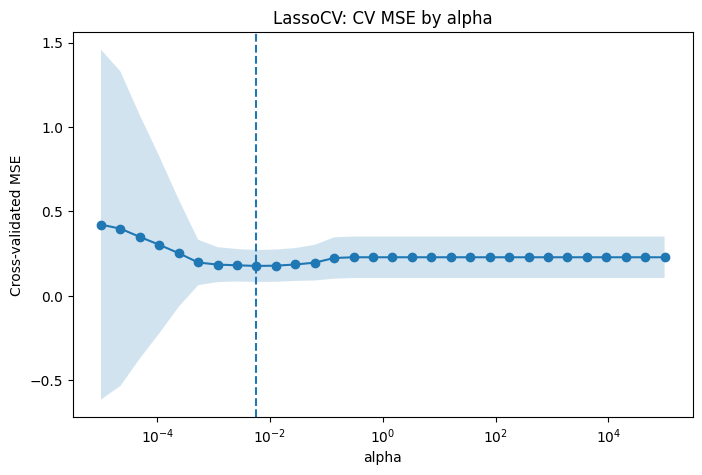

In [44]:
#4)
mean_mse = lasso_cv.mse_path_.mean(axis=1)
std_mse = lasso_cv.mse_path_.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker='o')
plt.fill_between(
    lasso_cv.alphas_,
    mean_mse - std_mse,
    mean_mse + std_mse,
    alpha=0.2
)
plt.axvline(lasso_cv.alpha_, linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LassoCV: CV MSE by alpha")
plt.show()

/Users/haileychong/Documents/Data Science/DS-3021 (ANALYTICS I)/undergrad_ml_assignments/undergrad_ml_assignments/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.087e-03, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(


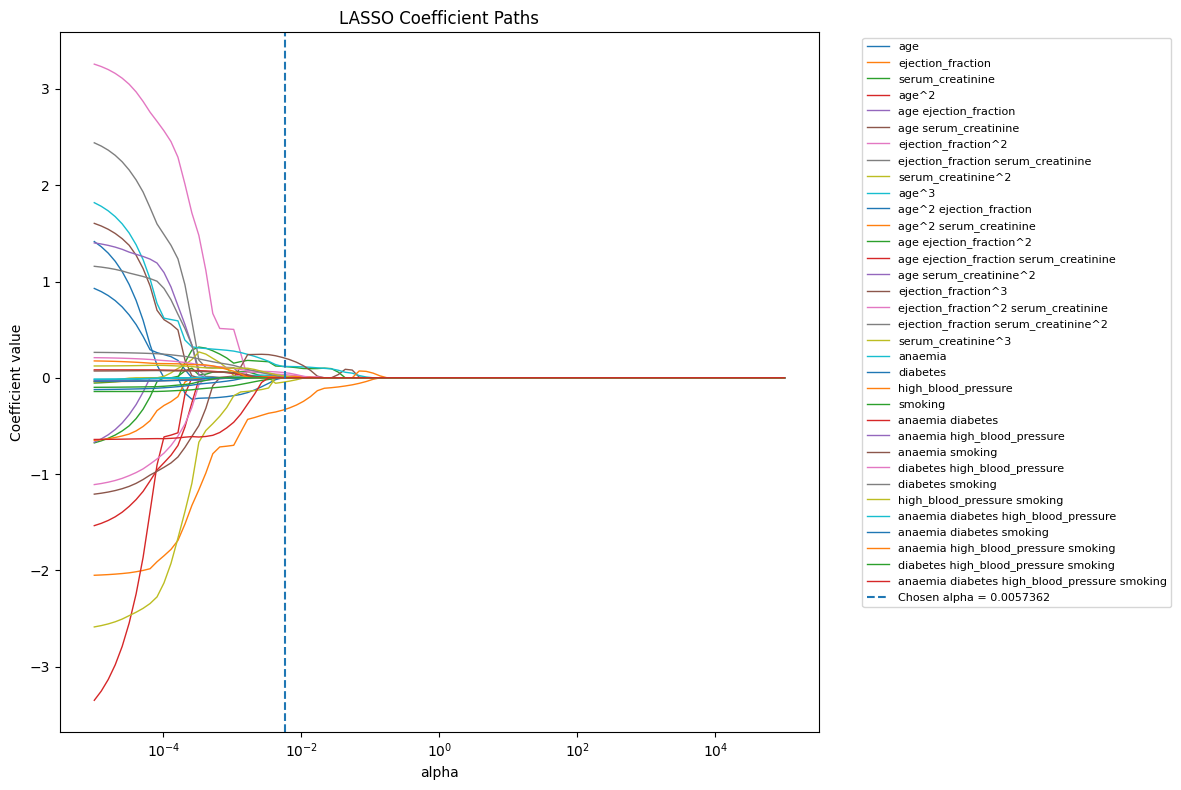

In [45]:
#5)

alpha_path = np.logspace(-5, 5, 100)
coef_path = []

for a in alpha_path:
    model = Lasso(alpha=a, max_iter=100000)
    model.fit(X, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

plt.figure(figsize=(12, 8))
for j, name in enumerate(feature_names):
    plt.semilogx(alpha_path, coef_path[:, j], linewidth=1, label=name)

plt.axvline(lasso_cv.alpha_, linestyle="--", label=f"Chosen alpha = {lasso_cv.alpha_:.5g}")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [46]:
#6)
comparison = pd.DataFrame({
    "linear_regression": lin_coefs,
    "lasso": lasso_coefs
})

comparison["selected_by_lasso"] = comparison["lasso"] != 0
comparison["set_to_zero_by_lasso"] = comparison["lasso"] == 0
comparison["abs_increased_in_lasso"] = comparison["lasso"].abs() > comparison["linear_regression"].abs()
comparison["sign_changed"] = (
    (comparison["linear_regression"] * comparison["lasso"] < 0)
)

selected_features = comparison.index[comparison["selected_by_lasso"]].tolist()
prop_zero = comparison["set_to_zero_by_lasso"].mean()

print("Selected features:")
for feat in selected_features:
    print("-", feat)

print("\nProportion set to zero by LASSO:", prop_zero)

print("\nComparison table:")
print(comparison.sort_values(["selected_by_lasso", "lasso"], ascending=[False, False]))

print("\nFeatures whose absolute coefficient got larger under LASSO:")
print(comparison[comparison["abs_increased_in_lasso"]][["linear_regression", "lasso"]])

print("\nFeatures whose sign changed from OLS to LASSO:")
print(comparison[comparison["sign_changed"]][["linear_regression", "lasso"]])

# Do the sign patterns for the linear_model or the Lasso seem to make more sense?
# LASSO often makes more sense by reducing overfitting. Linear regression may have unstable signs due to multicollinearity, while LASSO selects important features, leading to more interpretable and stable signs from bias-variance trade-off perspective.

Selected features:
- ejection_fraction
- serum_creatinine
- age^3
- ejection_fraction^3
- ejection_fraction^2 serum_creatinine
- serum_creatinine^3
- anaemia
- diabetes
- high_blood_pressure
- diabetes high_blood_pressure
- diabetes smoking
- high_blood_pressure smoking

Proportion set to zero by LASSO: 0.6470588235294118

Comparison table:
                                              linear_regression     lasso  \
ejection_fraction^3                                   -1.245337  0.204822   
age^3                                                  1.963124  0.117992   
serum_creatinine                                      -0.757092  0.116875   
diabetes high_blood_pressure                           0.212543  0.053968   
ejection_fraction^2 serum_creatinine                  -1.151378  0.032801   
high_blood_pressure smoking                            0.121481  0.017805   
anaemia                                               -0.015590  0.014178   
high_blood_pressure                      

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

#1)
The ridge regression objective function is the usual mean squared error plus a penalty on the slope coefficient. In this case, it is the average squared difference between the observed centered response and the predicted value, plus alpha times (b_1)^2 The intercept is not penalized.

#2)
Because both x and y are mean-centered, their sums are zero. That makes the intercept b_0 = 0.For the slope, after taking the derivative and solving, the ridge estimate becomes:

$b_1 = \frac{\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum \tilde{x}_i^2 + \alpha}$

So the slope is like the usual least-squares slope, except the denominator has an extra +α, which shrinks the estimate.


#3)
As alpha gets larger, the denominator gets larger, so the slope coefficient gets pushed closer to zero. That means the fitted line becomes flatter. If alpha is zero, ridge gives the same slope as ordinary least squares. If alpha becomes very large, the slope approaches zero.

#4)
With LASSO, the penalty is based on the absolute value of the slope instead of the square. The main issue is that the absolute value function is not differentiable at zero, so you cannot solve it with one smooth derivative the same way as ridge. Instead, you have to break it into cases: when the slope is positive, when it is negative, and when it is exactly zero. The important result is that LASSO can force the slope to be exactly zero if the relationship between x and y is not strong enough to overcome the penalty. Ridge shrinks coefficients toward zero, while LASSO can set them exactly equal to zero.